In [3]:
# ============================================================
# CHAPTER 4: RESULTS AND DISCUSSION
# MTN Customer Churn Prediction using Ensemble ML
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Load dataset
df = pd.read_csv('mtn_customer_churn.csv')

# First look at the data
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (974, 17)

Column names:
 ['Customer ID', 'Full Name', 'Date of Purchase', 'Age', 'State', 'MTN Device', 'Gender', 'Satisfaction Rate', 'Customer Review', 'Customer Tenure in months', 'Subscription Plan', 'Unit Price', 'Number of Times Purchased', 'Total Revenue', 'Data Usage', 'Customer Churn Status', 'Reasons for Churn']

First 5 rows:
   Customer ID     Full Name Date of Purchase  Age        State  \
0    CUST0001   Ngozi Berry           25-Jan   27        Kwara   
1    CUST0002  Zainab Baker           25-Mar   16  Abuja (FCT)   
2    CUST0003   Saidu Evans           25-Mar   21       Sokoto   
3    CUST0003   Saidu Evans           25-Mar   21       Sokoto   
4    CUST0003   Saidu Evans           25-Mar   21       Sokoto   

            MTN Device  Gender  Satisfaction Rate Customer Review  \
0            4G Router    Male                  2            Fair   
1      Mobile SIM Card  Female                  2            Fair   
2  5G Broadband Router    Male                  

In [4]:
print("Churn Distribution:")
print(df['Customer Churn Status'].value_counts())
print(f"\nChurn Rate: {(df['Customer Churn Status'] == 'Yes').mean()*100:.1f}%")
print(f"Retention Rate: {(df['Customer Churn Status'] == 'No').mean()*100:.1f}%")


Churn Distribution:
Customer Churn Status
No     690
Yes    284
Name: count, dtype: int64

Churn Rate: 29.2%
Retention Rate: 70.8%


In [5]:
# ============================================================
# STEP 1: DATA CLEANING
# ============================================================

# Drop identifier columns (not useful for prediction)
df.drop(columns=['Customer ID', 'Full Name'], inplace=True)

# Drop "Reasons for Churn" to avoid data leakage
# This column only has a value AFTER churn happens, 
# so including it would give the model an unfair advantage
df.drop(columns=['Reasons for Churn'], inplace=True)

# --- Handle Missing Values ---
# Check which columns have missing values
print("Missing values per column:")
print(df.isnull().sum())

# Fill missing numerical values with the median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Filled {col} with median: {df[col].median()}")

# Fill missing categorical values with the mode (most frequent)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  Filled {col} with mode: {df[col].mode()[0]}")

# Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"\nDuplicates removed: {before - after}")
print(f"Dataset size after cleaning: {df.shape}")

Missing values per column:
Date of Purchase             0
Age                          0
State                        0
MTN Device                   0
Gender                       0
Satisfaction Rate            0
Customer Review              0
Customer Tenure in months    0
Subscription Plan            0
Unit Price                   0
Number of Times Purchased    0
Total Revenue                0
Data Usage                   0
Customer Churn Status        0
dtype: int64

Duplicates removed: 0
Dataset size after cleaning: (974, 14)


In [6]:
# ============================================================
# SECTION 3: FEATURE ENGINEERING & PREPROCESSING
# ============================================================

print("="*55)
print("  FEATURE ENGINEERING & PREPROCESSING")
print("="*55)

# --- Step 1: Engineer New Features ---
# These new columns capture customer behaviour more meaningfully
# than the raw numbers alone

df['Revenue_per_month'] = df['Total Revenue'] / (df['Customer Tenure in months'] + 1)
df['Purchases_per_month'] = df['Number of Times Purchased'] / (df['Customer Tenure in months'] + 1)
df['Avg_revenue_per_purchase'] = df['Total Revenue'] / (df['Number of Times Purchased'] + 1)

print("\nNew engineered features created:")
print(df[['Revenue_per_month', 
          'Purchases_per_month', 
          'Avg_revenue_per_purchase']].describe().round(2))

# --- Step 2: Handle Date of Purchase ---
# This column only contains 3 month values: 25-Jan, 25-Feb, 25-Mar
# We extract the month name and convert to a number

month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3}
df['Purchase_Month'] = df['Date of Purchase'].str.extract(r'-(\w+)')[0].map(month_map)
df.drop(columns=['Date of Purchase'], inplace=True)

print("\nPurchase_Month distribution:")
print(df['Purchase_Month'].value_counts().sort_index())

# --- Step 3: Encode Customer Review (Ordinal) ---
# Poor=1, Fair=2, Good=3, Very Good=4, Excellent=5
# We use numbers because there IS a natural order here

review_map = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}
df['Customer Review'] = df['Customer Review'].map(review_map)

print("\nCustomer Review after ordinal encoding:")
print(df['Customer Review'].value_counts().sort_index())

# --- Step 4: Encode Target Variable ---
# Convert Yes/No to 1/0 so the model can process it

df['Customer Churn Status'] = df['Customer Churn Status'].map({'Yes': 1, 'No': 0})

print("\nTarget variable after encoding:")
print(df['Customer Churn Status'].value_counts())
print(f"Churn Rate: {df['Customer Churn Status'].mean()*100:.1f}%")

# --- Step 5: One-Hot Encode Remaining Categorical Columns ---
# These columns have no natural order so we use one-hot encoding

cat_cols = ['State', 'MTN Device', 'Gender', 'Subscription Plan']
print(f"\nCategorical columns to one-hot encode: {cat_cols}")

df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print(f"\nDataset shape after encoding: {df.shape}")

# --- Step 6: Separate Features (X) and Target (y) ---
X = df.drop(columns=['Customer Churn Status'])
y = df['Customer Churn Status']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)} total):")
print(X.columns.tolist())

  FEATURE ENGINEERING & PREPROCESSING

New engineered features created:
       Revenue_per_month  Purchases_per_month  Avg_revenue_per_purchase
count             974.00               974.00                    974.00
mean            11658.63                 0.59                  16762.78
std             29604.19                 0.93                  22704.84
min                 9.46                 0.02                    175.00
25%              1128.06                 0.18                   4263.16
50%              3600.00                 0.32                  11600.00
75%             10225.45                 0.58                  21860.80
max            450000.00                 9.50                 142857.14

Purchase_Month distribution:
Purchase_Month
1    271
2    450
3    253
Name: count, dtype: int64

Customer Review after ordinal encoding:
Customer Review
1    198
2    199
3    199
4    212
5    166
Name: count, dtype: int64

Target variable after encoding:
Customer Churn Status

In [8]:
# ============================================================
# SECTION 4: TRAIN-TEST SPLIT & SMOTE
# ============================================================

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("TRAIN-TEST SPLIT & CLASS IMBALANCE HANDLING")
print("="*50)

# Split into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Before SMOTE:")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")
print(f"Churn in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Churn in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Apply SMOTE on training data ONLY
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"Training set size: {X_train_sm.shape[0]} rows")
print(f"Churned: {y_train_sm.sum()} ({y_train_sm.mean()*100:.1f}%)")
print(f"Retained: {(y_train_sm==0).sum()} ({(y_train_sm==0).mean()*100:.1f}%)")
print("\nClass balance achieved in training data")
print("Test set remains untouched")

TRAIN-TEST SPLIT & CLASS IMBALANCE HANDLING
Before SMOTE:
Training set size: 779 rows
Test set size: 195 rows
Churn in training: 227 (29.1%)
Churn in test: 57 (29.2%)

After SMOTE:
Training set size: 1104 rows
Churned: 552 (50.0%)
Retained: 552 (50.0%)

Class balance achieved in training data
Test set remains untouched


In [10]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost'], check=True)

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0)

In [11]:
# ============================================================
# SECTION 5: MODEL TRAINING AND EVALUATION
# ============================================================

from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               AdaBoostClassifier,
                               StackingClassifier)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("="*55)
print("  MODEL TRAINING AND EVALUATION")
print("="*55)

# --- Helper Function ---
# This function trains any model and returns all metrics
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
          target_names=['Not Churned', 'Churned']))

    return {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model_obj': model
    }

  MODEL TRAINING AND EVALUATION


In [12]:
# ============================================================
# DEFINE AND TRAIN ALL 6 MODELS
# ============================================================

results = []

# --- Model 1: Logistic Regression (Baseline) ---
r_lr = evaluate_model(
    "Logistic Regression (Baseline)",
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_sm, y_train_sm, X_test, y_test
)
results.append({k: v for k, v in r_lr.items()
                if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Model 2: Random Forest ---
r_rf = evaluate_model(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results.append({k: v for k, v in r_rf.items()
                if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Model 3: Gradient Boosting ---
r_gbm = evaluate_model(
    "Gradient Boosting (GBM)",
    GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        random_state=42
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results.append({k: v for k, v in r_gbm.items()
                if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Model 4: XGBoost ---
r_xgb = evaluate_model(
    "XGBoost",
    XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results.append({k: v for k, v in r_xgb.items()
                if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Model 5: AdaBoost ---
r_ada = evaluate_model(
    "AdaBoost",
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results.append({k: v for k, v in r_ada.items()
                if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Model 6: Stacking Ensemble ---
r_stack = evaluate_model(
    "Stacking Ensemble",
    StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(
                n_estimators=100, random_state=42)),
            ('gbm', GradientBoostingClassifier(
                n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(
                n_estimators=100, eval_metric='logloss', random_state=42))
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results.append({k: v for k, v in r_stack.items()
                if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Summary Table ---
import pandas as pd
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("  COMPARATIVE PERFORMANCE SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to model_comparison_results.csv")


  Logistic Regression (Baseline)
  Accuracy  : 54.36%
  Precision : 0.2647
  Recall    : 0.3158
  F1-Score  : 0.2880
  ROC-AUC   : 0.4480

  Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.69      0.64      0.66       138
     Churned       0.26      0.32      0.29        57

    accuracy                           0.54       195
   macro avg       0.48      0.48      0.48       195
weighted avg       0.57      0.54      0.55       195


  Random Forest
  Accuracy  : 65.64%
  Precision : 0.3438
  Recall    : 0.1930
  F1-Score  : 0.2472
  ROC-AUC   : 0.5690

  Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.72      0.85      0.78       138
     Churned       0.34      0.19      0.25        57

    accuracy                           0.66       195
   macro avg       0.53      0.52      0.51       195
weighted avg       0.61      0.66      0.62       195


  Gradient Boosting (GBM)
  Accu

In [13]:
# ============================================================
# SECTION 5B: HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("="*55)
print("  HYPERPARAMETER TUNING")
print("="*55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Tune GBM (your best model) ---
print("\nTuning Gradient Boosting...")
gbm_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [2, 5, 10]
}
gbm_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gbm_params, n_iter=20, cv=cv,
    scoring='roc_auc', random_state=42, n_jobs=-1
)
gbm_search.fit(X_train_sm, y_train_sm)
print(f"Best GBM params: {gbm_search.best_params_}")
print(f"Best GBM CV AUC: {gbm_search.best_score_:.4f}")

# --- Tune XGBoost ---
print("\nTuning XGBoost...")
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params, n_iter=20, cv=cv,
    scoring='roc_auc', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_sm, y_train_sm)
print(f"Best XGBoost params: {xgb_search.best_params_}")
print(f"Best XGBoost CV AUC: {xgb_search.best_score_:.4f}")

# --- Tune Random Forest ---
print("\nTuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=20, cv=cv,
    scoring='roc_auc', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_sm, y_train_sm)
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF CV AUC: {rf_search.best_score_:.4f}")

print("\nHyperparameter tuning complete!")

  HYPERPARAMETER TUNING

Tuning Gradient Boosting...
Best GBM params: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.05}
Best GBM CV AUC: 0.8983

Tuning XGBoost...
Best XGBoost params: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best XGBoost CV AUC: 0.8756

Tuning Random Forest...
Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best RF CV AUC: 0.8957

Hyperparameter tuning complete!


In [14]:
# ============================================================
# SECTION 5C: RETRAIN MODELS WITH BEST PARAMETERS
# ============================================================

print("="*55)
print("  RETRAINING WITH BEST PARAMETERS")
print("="*55)

results_tuned = []

# --- Tuned GBM ---
r_gbm_tuned = evaluate_model(
    "GBM (Tuned)",
    GradientBoostingClassifier(
        subsample=0.9,
        n_estimators=300,
        min_samples_split=5,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results_tuned.append({k: v for k, v in r_gbm_tuned.items()
                      if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Tuned XGBoost ---
r_xgb_tuned = evaluate_model(
    "XGBoost (Tuned)",
    XGBClassifier(
        subsample=0.9,
        reg_lambda=1,
        reg_alpha=0,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results_tuned.append({k: v for k, v in r_xgb_tuned.items()
                      if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Tuned Random Forest ---
r_rf_tuned = evaluate_model(
    "Random Forest (Tuned)",
    RandomForestClassifier(
        n_estimators=200,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='log2',
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    X_train_sm, y_train_sm, X_test, y_test
)
results_tuned.append({k: v for k, v in r_rf_tuned.items()
                      if k not in ['y_pred', 'y_prob', 'model_obj']})

# --- Full Comparison: Before vs After Tuning ---
print("\n" + "="*70)
print("  BEFORE vs AFTER TUNING COMPARISON")
print("="*70)

comparison = pd.DataFrame([
    # Before tuning
    {'Model': 'GBM (Default)',        'Accuracy': 0.6872, 
     'F1-Score': 0.3838, 'ROC-AUC': 0.6438, 'Version': 'Before'},
    {'Model': 'XGBoost (Default)',     'Accuracy': 0.6513, 
     'F1-Score': 0.3061, 'ROC-AUC': 0.6269, 'Version': 'Before'},
    {'Model': 'Random Forest (Default)','Accuracy': 0.6564, 
     'F1-Score': 0.2472, 'ROC-AUC': 0.5690, 'Version': 'Before'},
    # After tuning
    {'Model': 'GBM (Tuned)',           
     'Accuracy': r_gbm_tuned['Accuracy'],
     'F1-Score': r_gbm_tuned['F1-Score'], 
     'ROC-AUC': r_gbm_tuned['ROC-AUC'],   'Version': 'After'},
    {'Model': 'XGBoost (Tuned)',        
     'Accuracy': r_xgb_tuned['Accuracy'],
     'F1-Score': r_xgb_tuned['F1-Score'], 
     'ROC-AUC': r_xgb_tuned['ROC-AUC'],   'Version': 'After'},
    {'Model': 'Random Forest (Tuned)', 
     'Accuracy': r_rf_tuned['Accuracy'],
     'F1-Score': r_rf_tuned['F1-Score'], 
     'ROC-AUC': r_rf_tuned['ROC-AUC'],    'Version': 'After'},
])

print(comparison.to_string(index=False))
comparison.to_csv('tuning_comparison.csv', index=False)
print("\nComparison saved to tuning_comparison.csv")

  RETRAINING WITH BEST PARAMETERS

  GBM (Tuned)
  Accuracy  : 69.23%
  Precision : 0.4667
  Recall    : 0.3684
  F1-Score  : 0.4118
  ROC-AUC   : 0.6609

  Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.76      0.83      0.79       138
     Churned       0.47      0.37      0.41        57

    accuracy                           0.69       195
   macro avg       0.61      0.60      0.60       195
weighted avg       0.67      0.69      0.68       195


  XGBoost (Tuned)
  Accuracy  : 70.26%
  Precision : 0.4878
  Recall    : 0.3509
  F1-Score  : 0.4082
  ROC-AUC   : 0.6482

  Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.76      0.85      0.80       138
     Churned       0.49      0.35      0.41        57

    accuracy                           0.70       195
   macro avg       0.62      0.60      0.60       195
weighted avg       0.68      0.70      0.69       195


  Random Forest

  GENERATING ALL VISUALIZATIONS


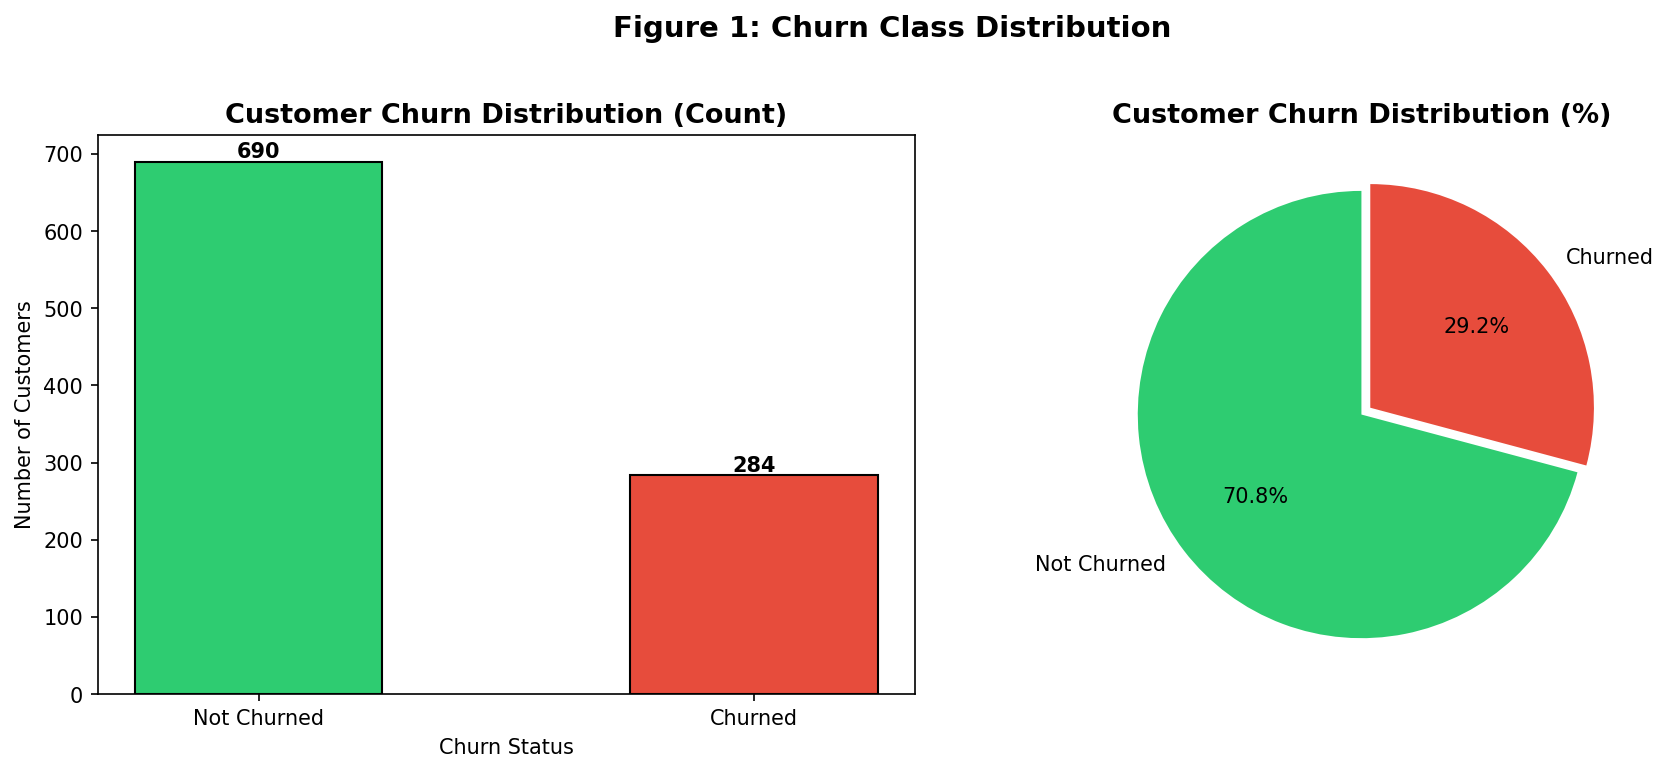

Figure 1 saved.


In [27]:
# ============================================================
# SECTION 6: VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns

print("="*55)
print("  GENERATING ALL VISUALIZATIONS")
print("="*55)

# --- Figure 1: Churn Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = pd.Series({'Not Churned': 690, 'Churned': 284})
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Customer Churn Distribution (Count)',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Churn Status')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values,
            labels=churn_counts.index,
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Customer Churn Distribution (%)',
                   fontsize=13, fontweight='bold')

plt.suptitle('Figure 1: Churn Class Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

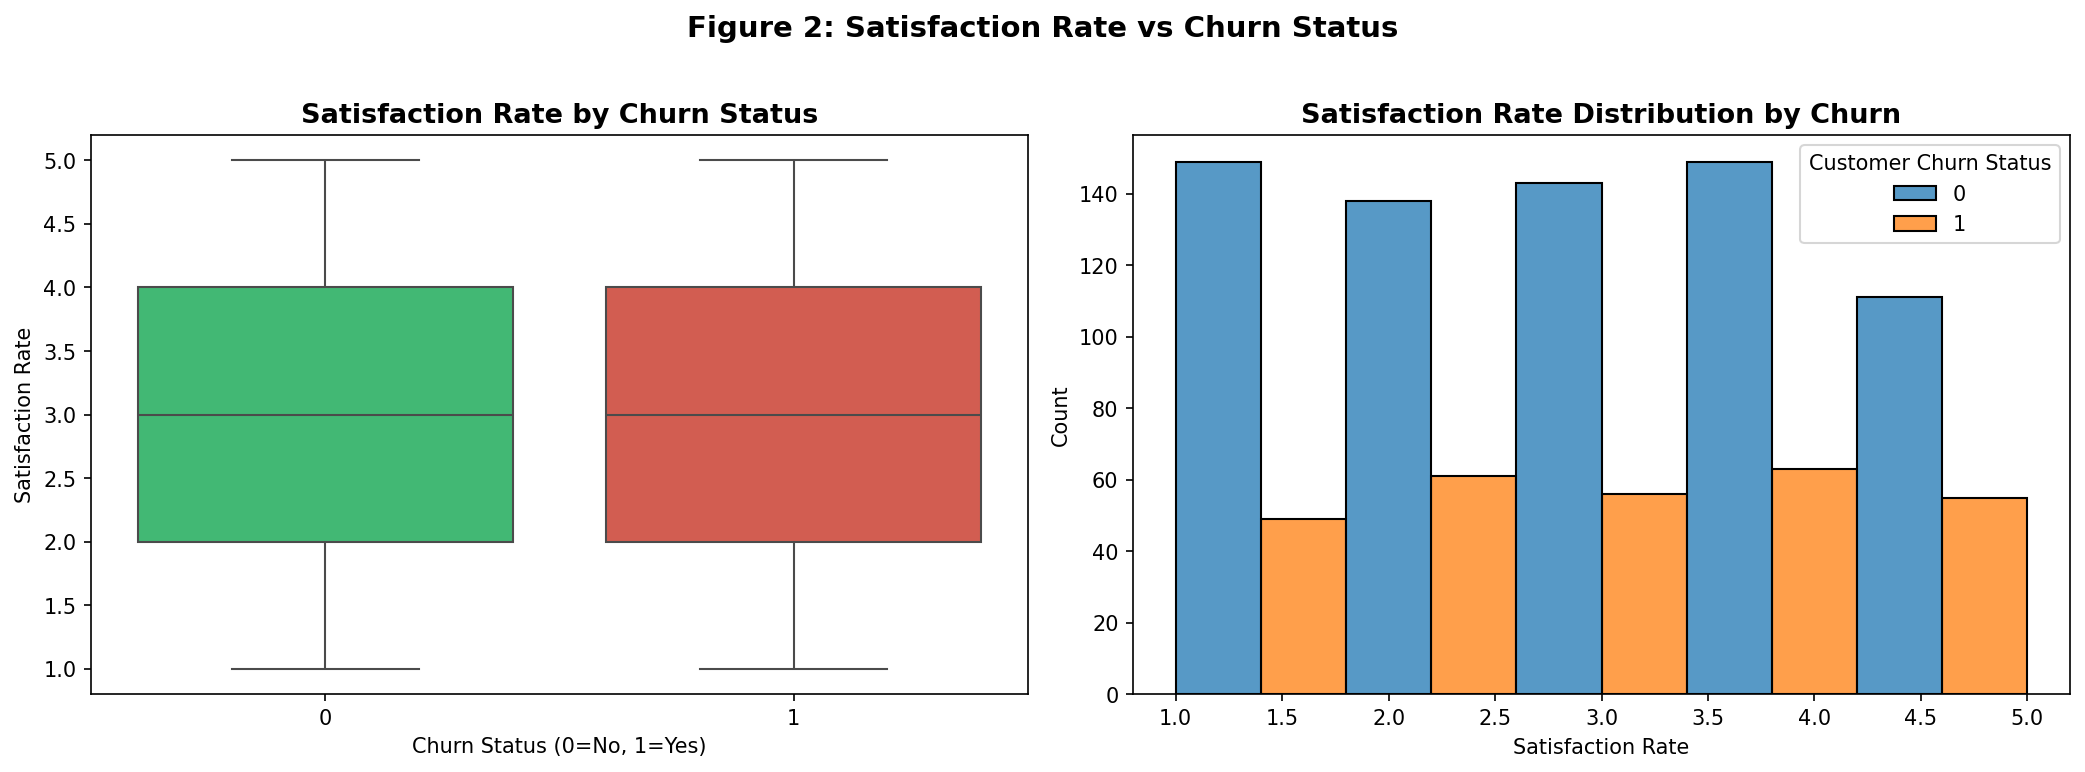

Figure 2 saved.


In [17]:
# --- Figure 2: Satisfaction Rate vs Churn ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Customer Churn Status', y='Satisfaction Rate',
            data=df, palette={'1': '#e74c3c', '0': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Satisfaction Rate by Churn Status',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Status (0=No, 1=Yes)')
axes[0].set_ylabel('Satisfaction Rate')

sns.histplot(data=df, x='Satisfaction Rate',
             hue='Customer Churn Status',
             multiple='dodge',
             ax=axes[1], bins=5)
axes[1].set_title('Satisfaction Rate Distribution by Churn',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Satisfaction Rate')

plt.suptitle('Figure 2: Satisfaction Rate vs Churn Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_satisfaction_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

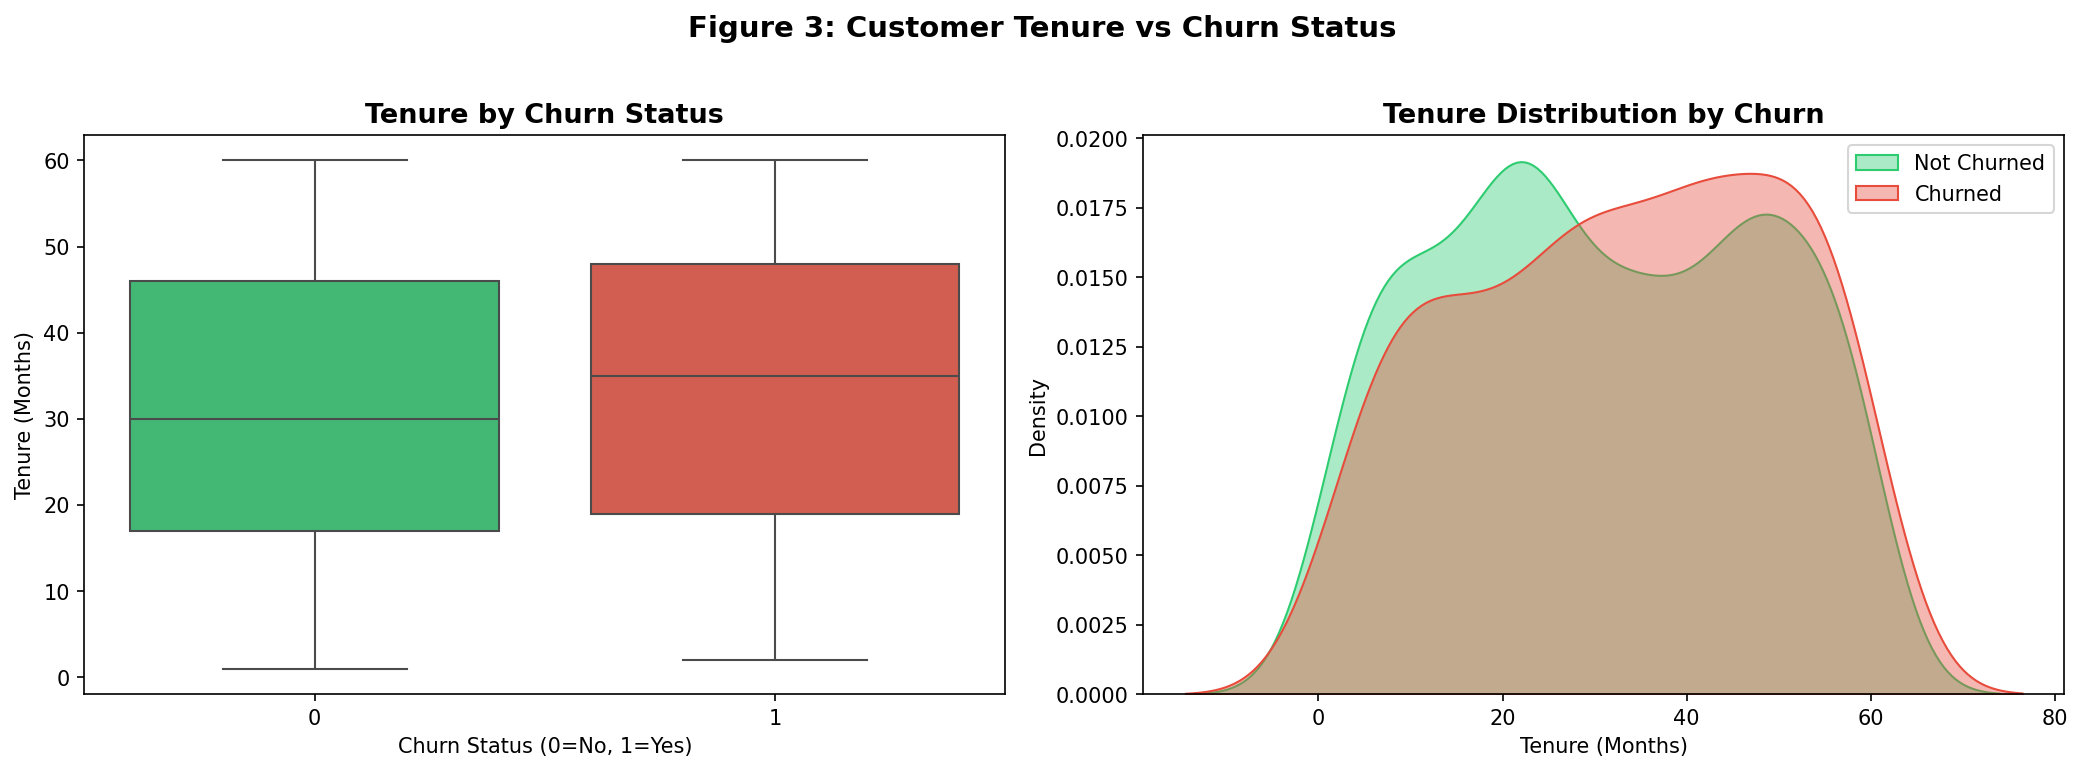

Figure 3 saved.


In [20]:
# --- Figure 3 FIXED: Tenure vs Churn ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Customer Churn Status', y='Customer Tenure in months',
            data=df, palette={'1': '#e74c3c', '0': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Tenure by Churn Status',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Status (0=No, 1=Yes)')
axes[0].set_ylabel('Tenure (Months)')

# Fix: convert to int for filtering
sns.kdeplot(data=df[df['Customer Churn Status'].astype(int)==0],
            x='Customer Tenure in months',
            label='Not Churned', color='#2ecc71',
            fill=True, alpha=0.4, ax=axes[1])
sns.kdeplot(data=df[df['Customer Churn Status'].astype(int)==1],
            x='Customer Tenure in months',
            label='Churned', color='#e74c3c',
            fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].legend()

plt.suptitle('Figure 3: Customer Tenure vs Churn Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

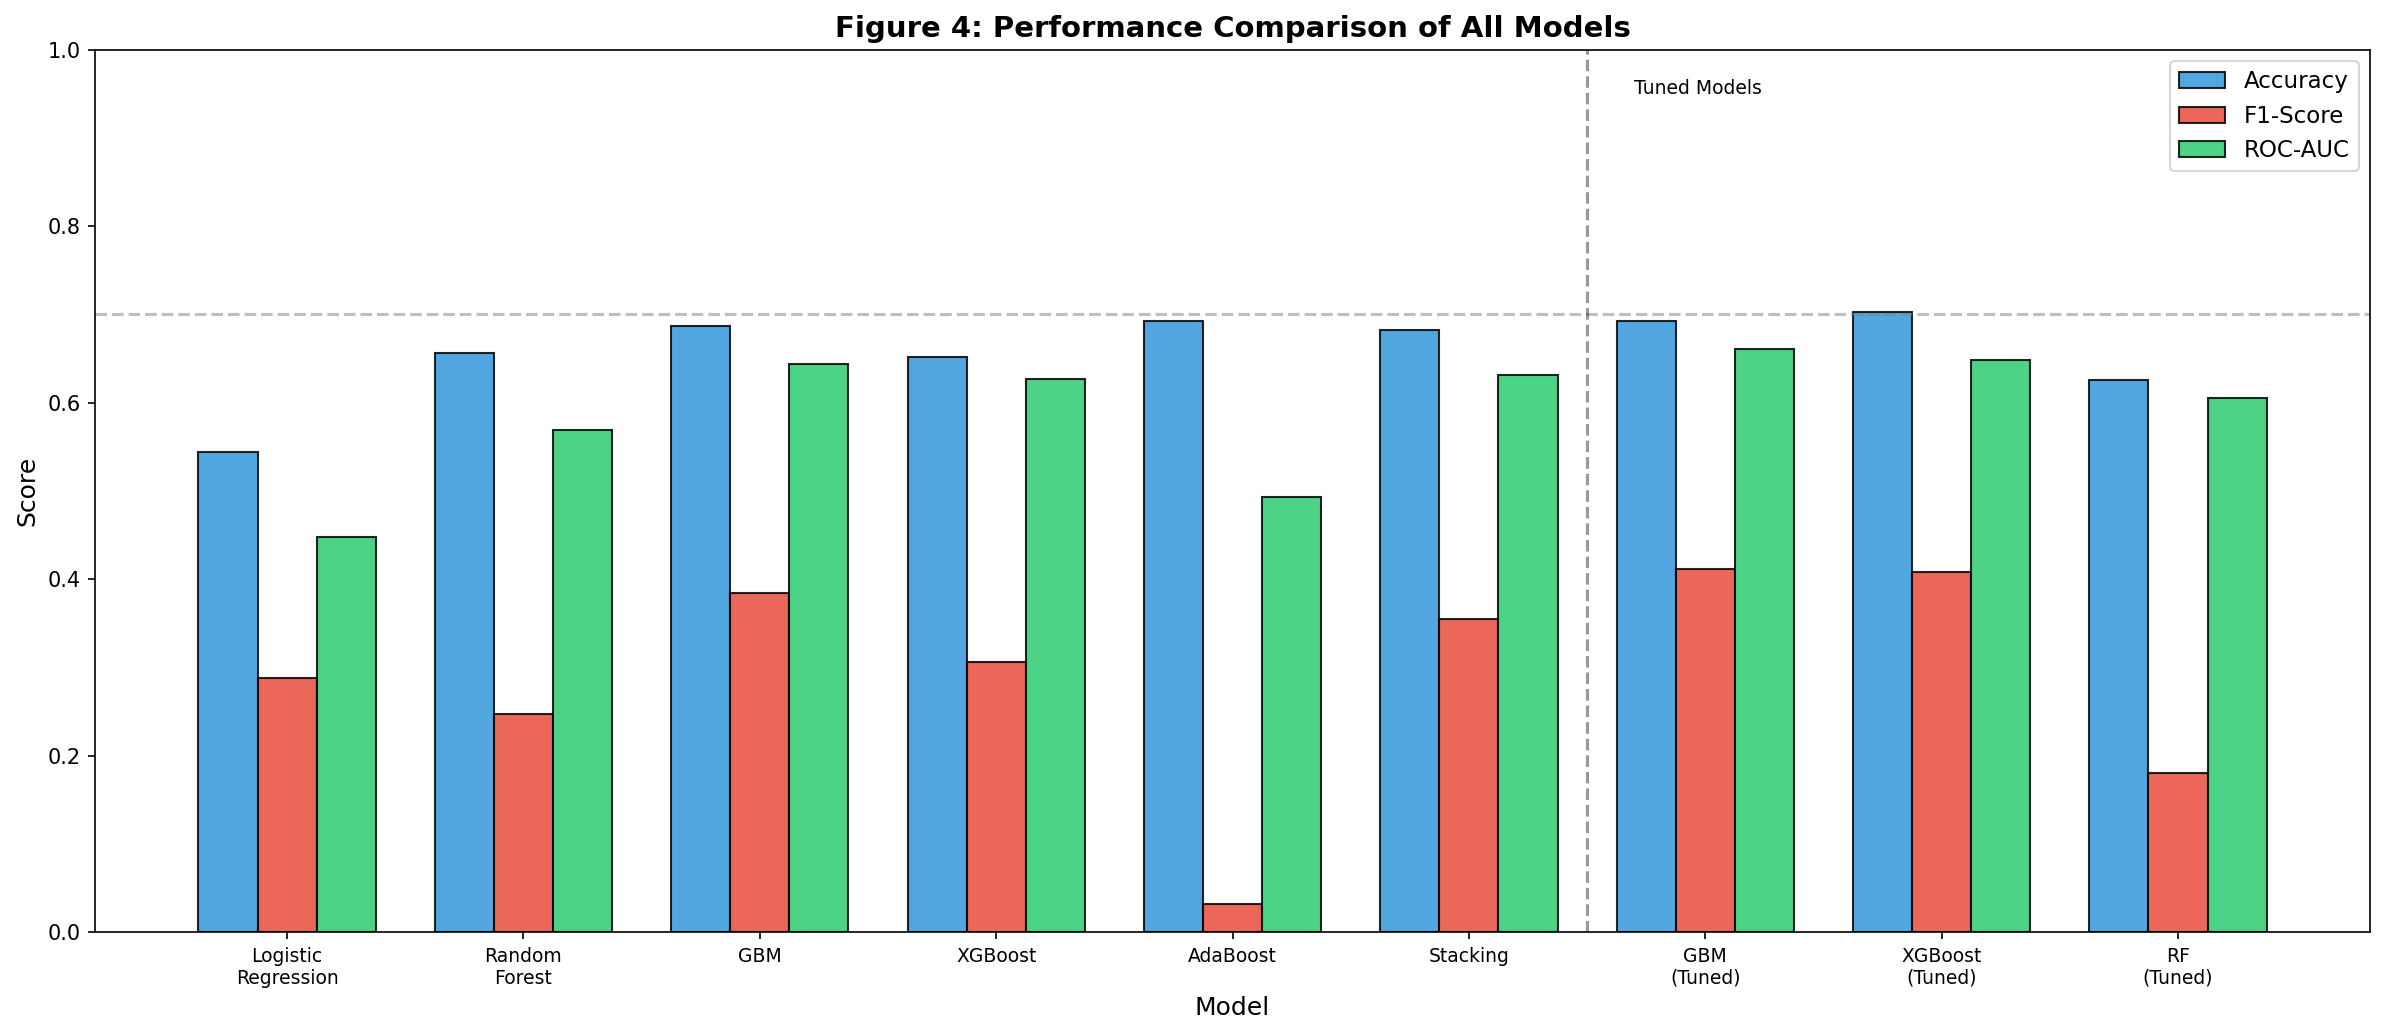

Figure 4 saved.


In [21]:
# --- Figure 4: Model Comparison Bar Chart ---
models_plot = ['Logistic\nRegression', 'Random\nForest', 'GBM',
               'XGBoost', 'AdaBoost', 'Stacking',
               'GBM\n(Tuned)', 'XGBoost\n(Tuned)', 'RF\n(Tuned)']

accuracy = [0.5436, 0.6564, 0.6872, 0.6513, 0.6923, 0.6821,
            0.6923, 0.7026, 0.6256]
f1       = [0.2880, 0.2472, 0.3838, 0.3061, 0.0323, 0.3542,
            0.4118, 0.4082, 0.1798]
auc      = [0.4480, 0.5690, 0.6438, 0.6269, 0.4931, 0.6309,
            0.6609, 0.6482, 0.6049]

x = np.arange(len(models_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - width, accuracy, width, label='Accuracy',
       color='#3498db', edgecolor='black', alpha=0.85)
ax.bar(x, f1, width, label='F1-Score',
       color='#e74c3c', edgecolor='black', alpha=0.85)
ax.bar(x + width, auc, width, label='ROC-AUC',
       color='#2ecc71', edgecolor='black', alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 4: Performance Comparison of All Models',
              fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_plot, fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=5.5, color='black', linestyle='--', alpha=0.4)
ax.text(5.7, 0.95, 'Tuned Models', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

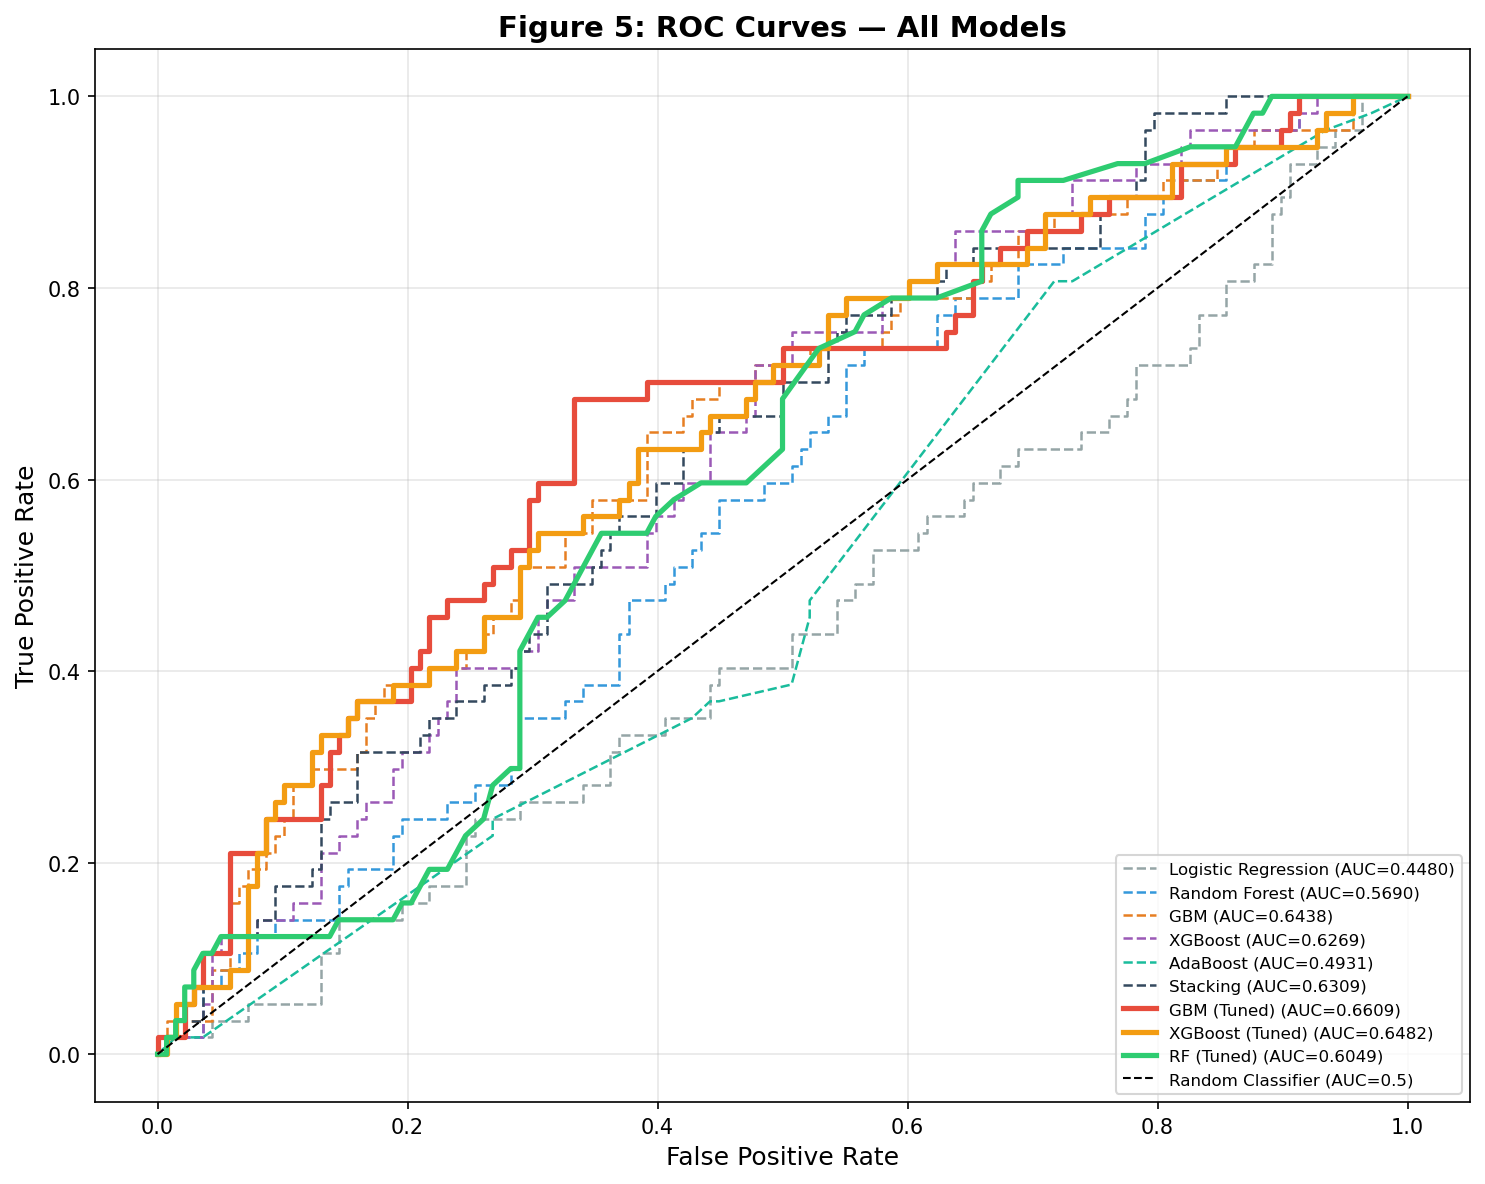

Figure 5 saved.


In [22]:
# --- Figure 5: ROC Curves ---
plt.figure(figsize=(10, 8))
colors = ['#95a5a6', '#3498db', '#e67e22',
          '#9b59b6', '#1abc9c', '#34495e',
          '#e74c3c', '#f39c12', '#2ecc71']

roc_models = [
    ("Logistic Regression", r_lr['model_obj']),
    ("Random Forest", r_rf['model_obj']),
    ("GBM", r_gbm['model_obj']),
    ("XGBoost", r_xgb['model_obj']),
    ("AdaBoost", r_ada['model_obj']),
    ("Stacking", r_stack['model_obj']),
    ("GBM (Tuned)", r_gbm_tuned['model_obj']),
    ("XGBoost (Tuned)", r_xgb_tuned['model_obj']),
    ("RF (Tuned)", r_rf_tuned['model_obj'])
]

for i, (name, model) in enumerate(roc_models):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    lw = 2.5 if 'Tuned' in name else 1.2
    ls = '-' if 'Tuned' in name else '--'
    plt.plot(fpr, tpr, color=colors[i], lw=lw, ls=ls,
             label=f'{name} (AUC={auc_score:.4f})')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Figure 5: ROC Curves — All Models',
           fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

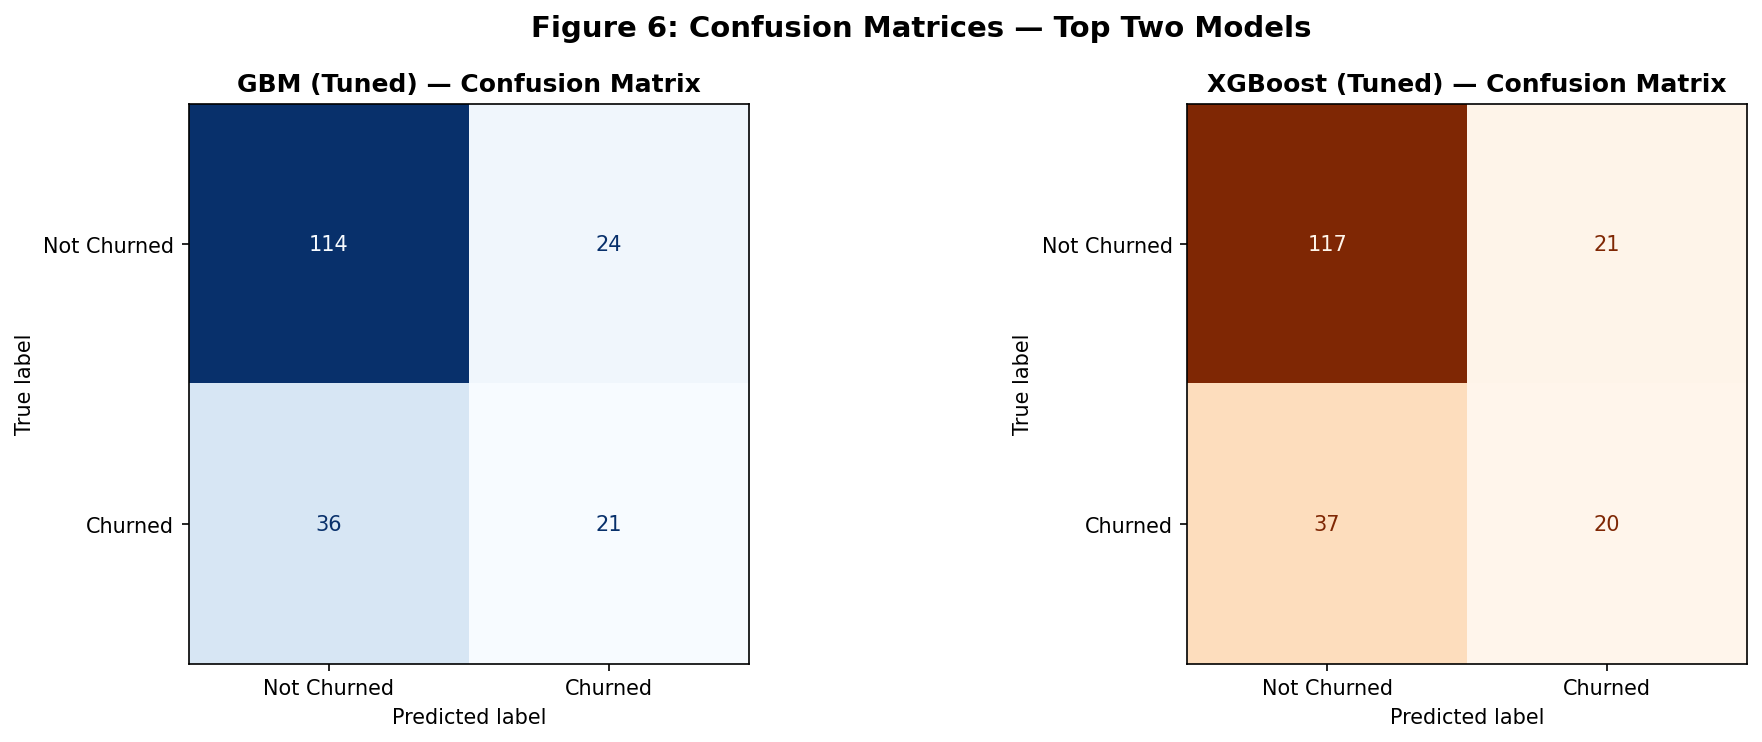


GBM (Tuned) Confusion Matrix Breakdown:
  True Positives  (TP) = 21  — Churners correctly caught
  True Negatives  (TN) = 114  — Non-churners correctly identified
  False Positives (FP) = 24  — Non-churners wrongly flagged
  False Negatives (FN) = 36  — Churners the model missed

Figure 6 saved.


In [23]:
# --- Figure 6: Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GBM Tuned
cm_gbm = confusion_matrix(y_test, r_gbm_tuned['y_pred'])
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_gbm,
                                display_labels=['Not Churned','Churned'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('GBM (Tuned) — Confusion Matrix',
                   fontsize=12, fontweight='bold')

# XGBoost Tuned
cm_xgb = confusion_matrix(y_test, r_xgb_tuned['y_pred'])
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                                display_labels=['Not Churned','Churned'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('XGBoost (Tuned) — Confusion Matrix',
                   fontsize=12, fontweight='bold')

plt.suptitle('Figure 6: Confusion Matrices — Top Two Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Print interpretation
tn, fp, fn, tp = cm_gbm.ravel()
print(f"\nGBM (Tuned) Confusion Matrix Breakdown:")
print(f"  True Positives  (TP) = {tp}  — Churners correctly caught")
print(f"  True Negatives  (TN) = {tn}  — Non-churners correctly identified")
print(f"  False Positives (FP) = {fp}  — Non-churners wrongly flagged")
print(f"  False Negatives (FN) = {fn}  — Churners the model missed")
print("\nFigure 6 saved.")

  FEATURE IMPORTANCE ANALYSIS


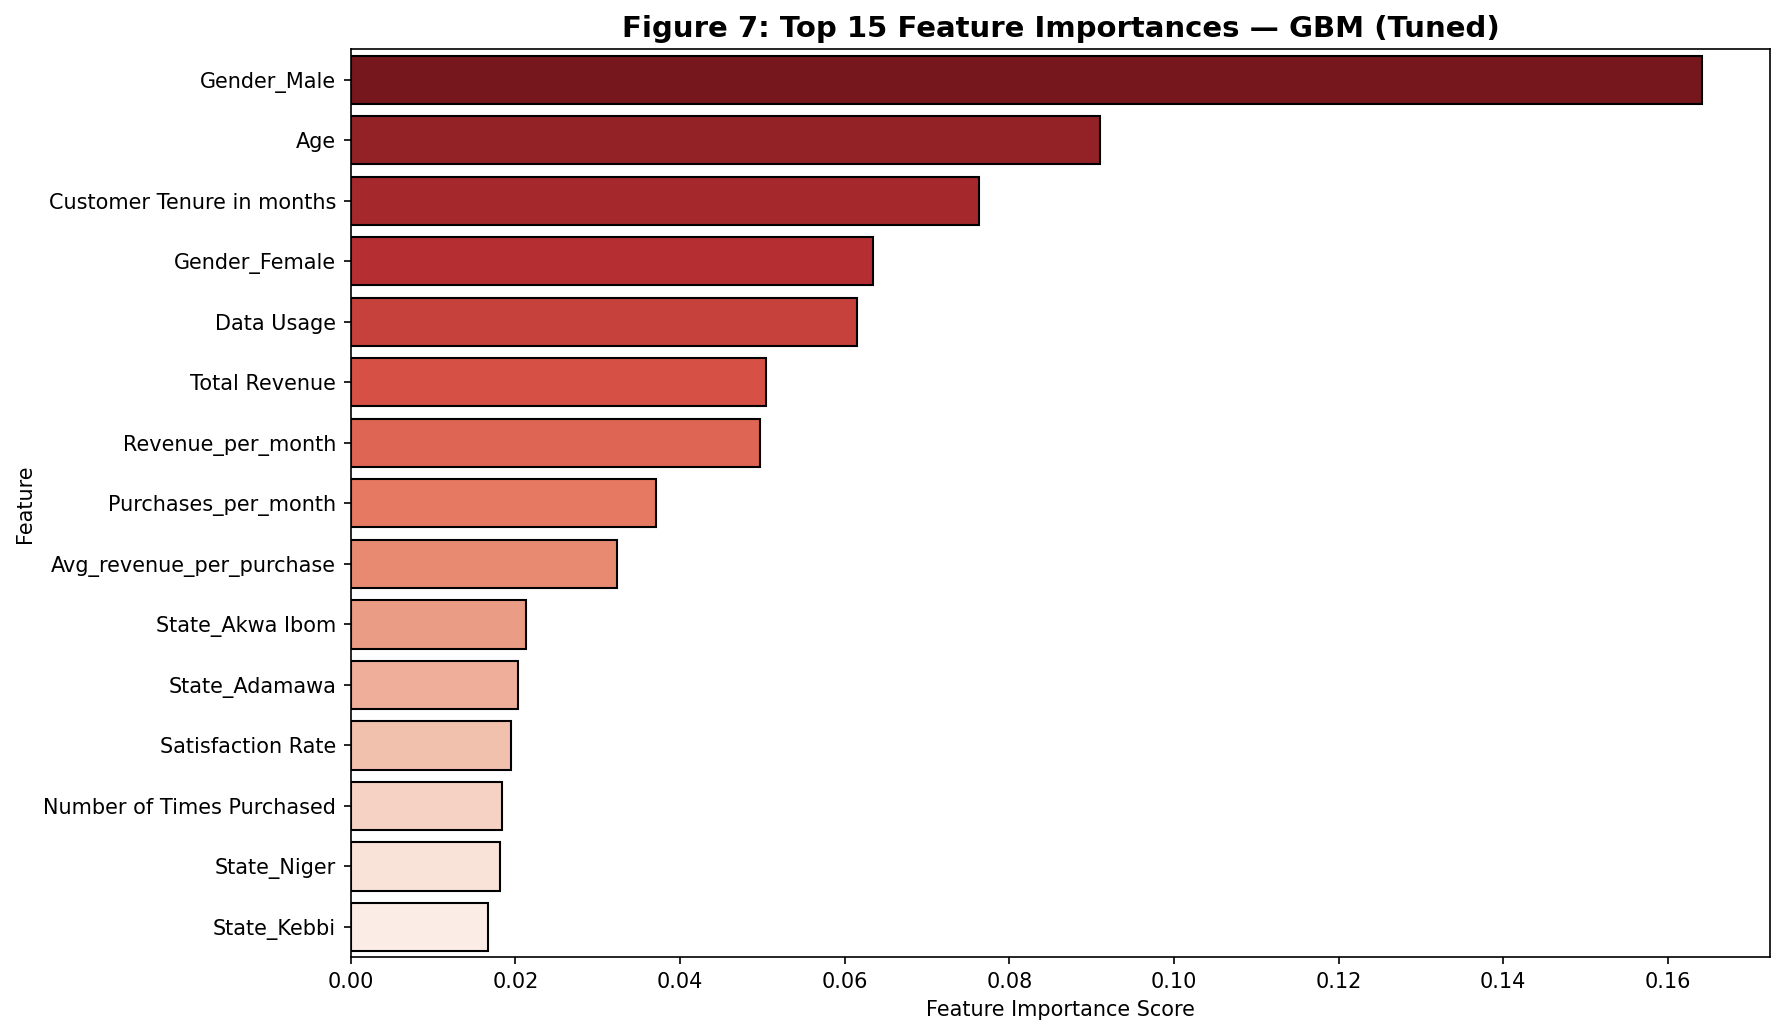

Figure 7 saved.

Top 15 Features (GBM Tuned):
                  Feature  Importance
              Gender_Male    0.164200
                      Age    0.091046
Customer Tenure in months    0.076338
            Gender_Female    0.063425
               Data Usage    0.061523
            Total Revenue    0.050475
        Revenue_per_month    0.049678
      Purchases_per_month    0.037067
 Avg_revenue_per_purchase    0.032392
          State_Akwa Ibom    0.021254
            State_Adamawa    0.020317
        Satisfaction Rate    0.019498
Number of Times Purchased    0.018321
              State_Niger    0.018124
              State_Kebbi    0.016709


In [25]:
# ============================================================
# SECTION 7: FEATURE IMPORTANCE ANALYSIS
# ============================================================

print("="*55)
print("  FEATURE IMPORTANCE ANALYSIS")
print("="*55)

# --- Figure 7: GBM Tuned Feature Importance ---
gbm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': r_gbm_tuned['model_obj'].feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', 
            data=gbm_importance, palette='Reds_r',
            edgecolor='black')
plt.title('Figure 7: Top 15 Feature Importances — GBM (Tuned)',
           fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('fig7_gbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")
print("\nTop 15 Features (GBM Tuned):")
print(gbm_importance.to_string(index=False))

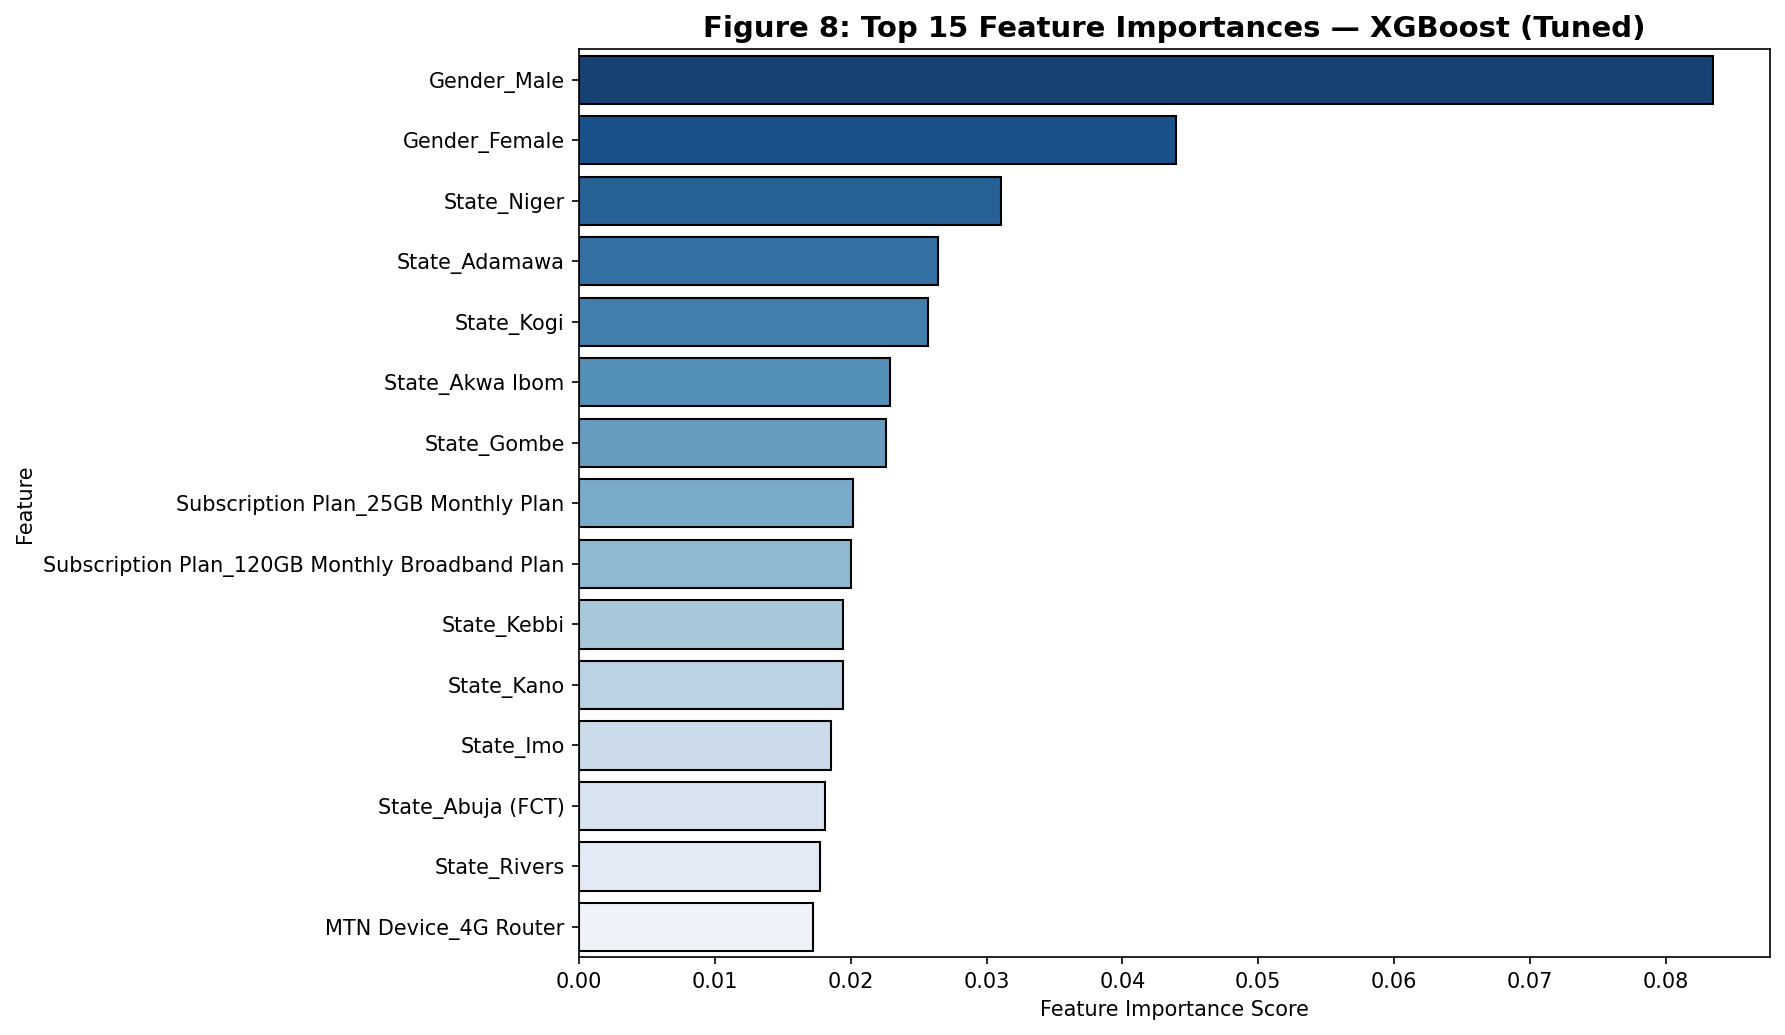

Figure 8 saved.

Top 15 Features (XGBoost Tuned):
                                       Feature  Importance
                                   Gender_Male    0.083515
                                 Gender_Female    0.043932
                                   State_Niger    0.031084
                                 State_Adamawa    0.026422
                                    State_Kogi    0.025679
                               State_Akwa Ibom    0.022883
                                   State_Gombe    0.022568
           Subscription Plan_25GB Monthly Plan    0.020162
Subscription Plan_120GB Monthly Broadband Plan    0.019974
                                   State_Kebbi    0.019443
                                    State_Kano    0.019390
                                     State_Imo    0.018565
                             State_Abuja (FCT)    0.018108
                                  State_Rivers    0.017704
                          MTN Device_4G Router    0.017236


In [26]:
# --- Figure 8: XGBoost Tuned Feature Importance ---
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': r_xgb_tuned['model_obj'].feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature',
            data=xgb_importance, palette='Blues_r',
            edgecolor='black')
plt.title('Figure 8: Top 15 Feature Importances — XGBoost (Tuned)',
           fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('fig8_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")
print("\nTop 15 Features (XGBoost Tuned):")
print(xgb_importance.to_string(index=False))

In [29]:
import subprocess
subprocess.run(['pip', 'install', 'shap'], check=True)


CompletedProcess(args=['pip', 'install', 'shap'], returncode=0)

In [30]:
# ============================================================
# SECTION 8: SHAP ANALYSIS
# ============================================================

import shap

print("="*55)
print("  SHAP EXPLAINABILITY ANALYSIS")
print("="*55)

# Create SHAP explainer using best model (GBM Tuned)
explainer = shap.TreeExplainer(r_gbm_tuned['model_obj'])
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully.")
print(f"Shape of SHAP values: {shap_values.shape}")

  SHAP EXPLAINABILITY ANALYSIS
SHAP values computed successfully.
Shape of SHAP values: (195, 74)


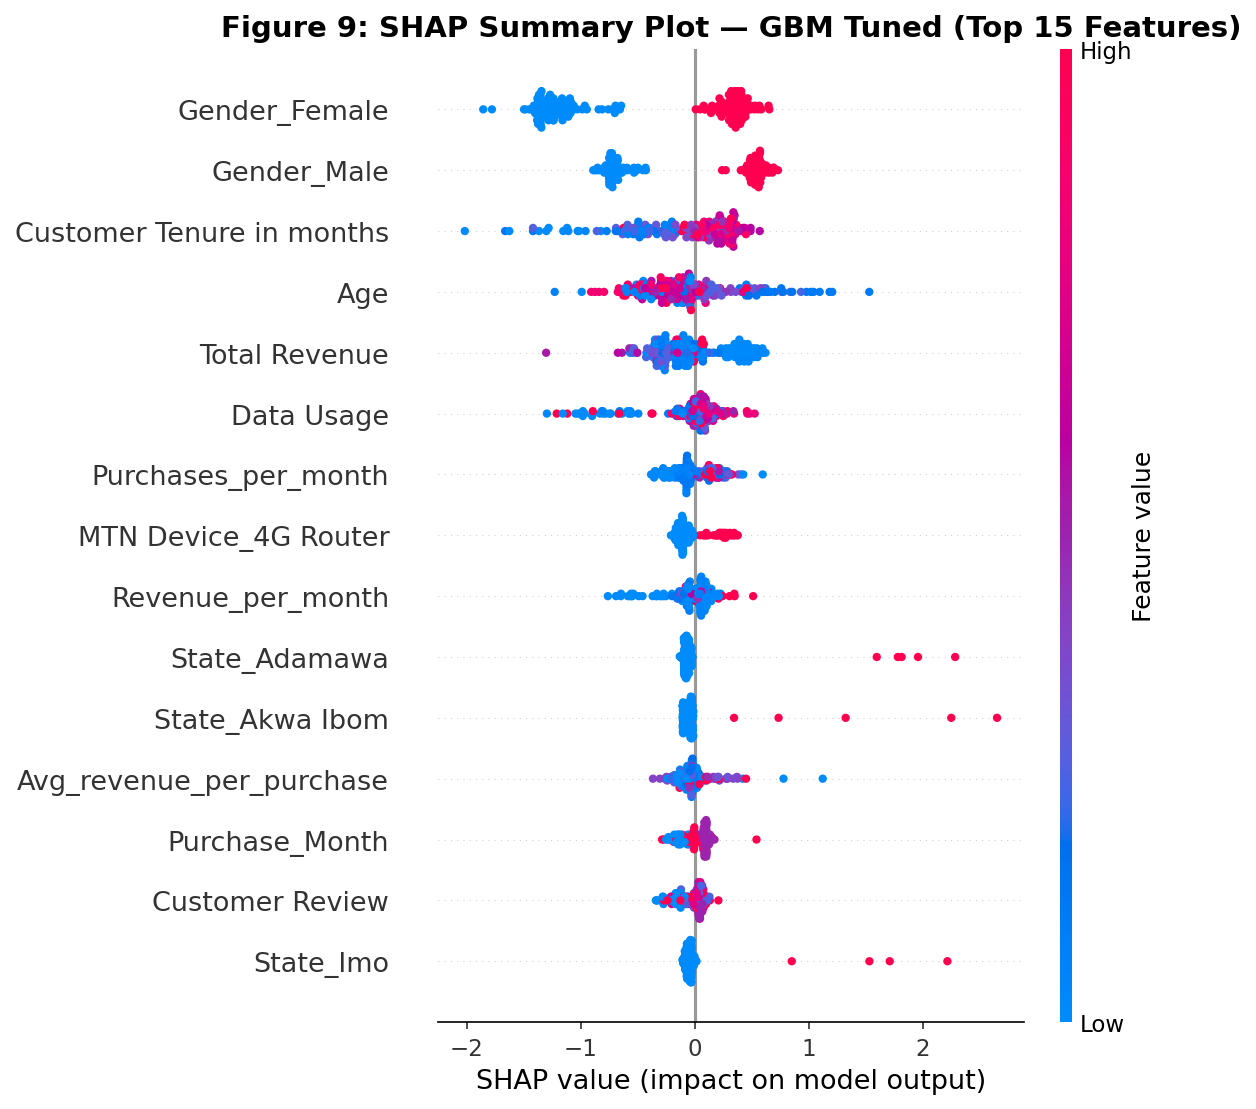

Figure 9 saved.


In [31]:
# --- Figure 9: SHAP Summary Plot ---
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test,
                   feature_names=X.columns.tolist(),
                   max_display=15,
                   show=False)
plt.title('Figure 9: SHAP Summary Plot — GBM Tuned (Top 15 Features)',
           fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

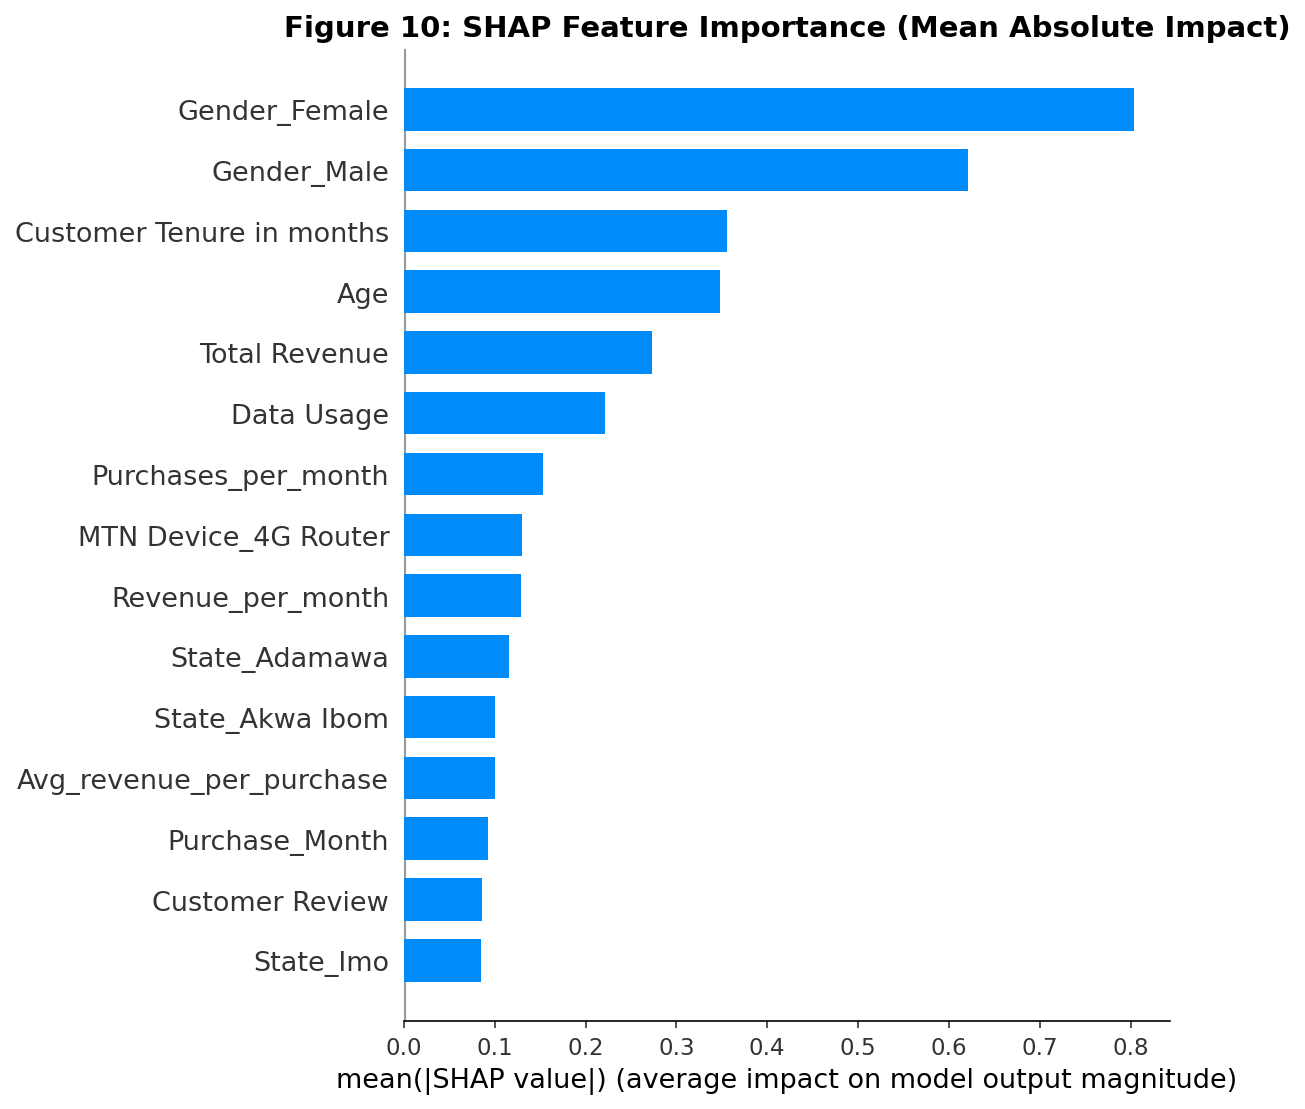

Figure 10 saved.


In [32]:
# --- Figure 10: SHAP Bar Plot ---
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test,
                   feature_names=X.columns.tolist(),
                   plot_type='bar',
                   max_display=15,
                   show=False)
plt.title('Figure 10: SHAP Feature Importance (Mean Absolute Impact)',
           fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

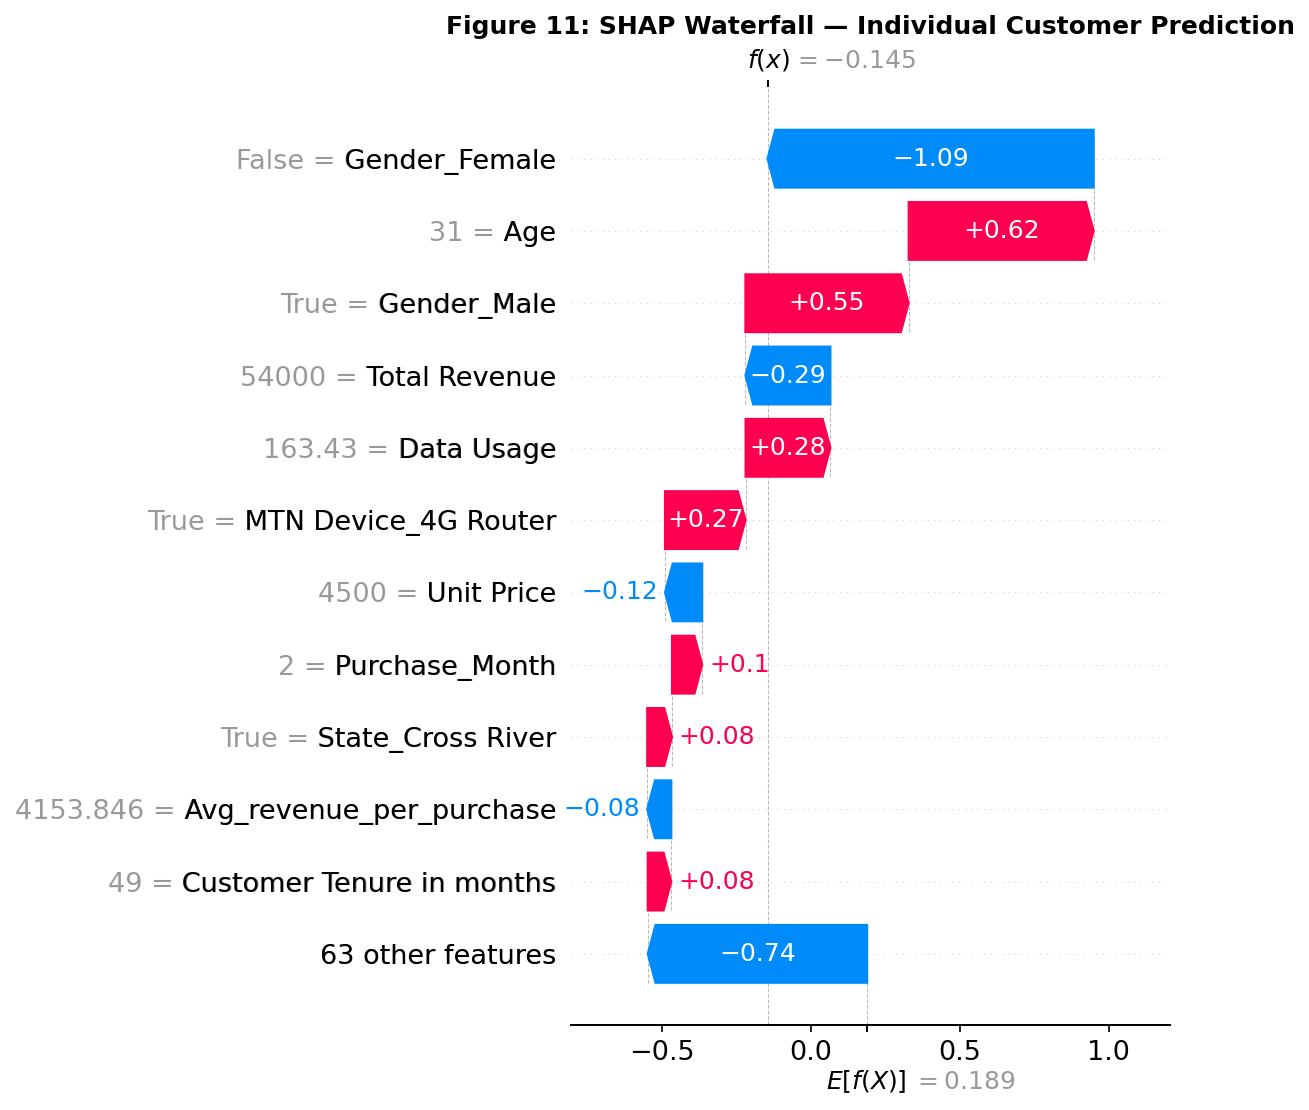

Figure 11 saved.

Customer Sample 0 Prediction:
  Actual Churn Status : 0
  Predicted Churn Prob: 0.4637
  Predicted Class     : 0


In [33]:
# --- Figure 11: SHAP Waterfall Plot ---
# This explains one individual customer prediction
sample_idx = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx].values,
        feature_names=X.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title('Figure 11: SHAP Waterfall — Individual Customer Prediction',
           fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

# Print what the model predicted for this customer
print(f"\nCustomer Sample {sample_idx} Prediction:")
print(f"  Actual Churn Status : {y_test.iloc[sample_idx]}")
print(f"  Predicted Churn Prob: {r_gbm_tuned['y_prob'][sample_idx]:.4f}")
print(f"  Predicted Class     : {r_gbm_tuned['y_pred'][sample_idx]}")